In [19]:
import sys, os, importlib.util
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

# Ensure working directory is reproduce_results/ so relative paths (../conf, ../results) resolve correctly
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('plot_figures_in_the_paper.ipynb'))
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, os.path.abspath('..'))

# ── Import plot_figures_for_avusi_pipeline ────────────────────────────────────
from plot_figures_for_avusi_pipeline import (
    generate_avusi_demo_data,
    plot_avusi_pipeline,
)

# ── Import plot_figures_for_the paper (space in filename → importlib) ─────────
_spec = importlib.util.spec_from_file_location(
    "plot_figures_for_the_paper",
    os.path.join(NOTEBOOK_DIR, "plot_figures_for_the paper.py"),
)
pfp = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(pfp)

from plot_figures_for_avusi_pipeline import generate_avusi_demo_data, plot_avusi_pipeline
from types import SimpleNamespace

# Re-export all public plot functions into the notebook namespace for convenience
load_dataset                              = pfp.load_dataset
plot_combined_three_metrics_boxplot       = pfp.plot_combined_three_metrics_boxplot
plot_combined_three_metrics_boxplot_horizontal = pfp.plot_combined_three_metrics_boxplot_horizontal
plot_combined_average_ranking             = pfp.plot_combined_average_ranking
plot_critical_difference                  = pfp.plot_critical_difference
plot_combined_hyper_parameter_sensitivity = pfp.plot_combined_hyper_parameter_sensitivity
plot_combined_computation_time            = pfp.plot_combined_computation_time
plot_compact_computation_time             = pfp.plot_compact_computation_time
plot_time_complexity_vs_series_length     = pfp.plot_time_complexity_vs_series_length
plot_metrics_for_a_single_time_series     = pfp.plot_metrics_for_a_single_time_series
plot_vusi_curve                           = pfp.plot_vusi_curve

OUTPUT_DIR = pfp.OUTPUT_DIR
DATASET_NAMES = pfp.DATASET_NAMES
print("All functions imported. OUTPUT_DIR:", OUTPUT_DIR)

All functions imported. OUTPUT_DIR: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures


## Load datasets

In [20]:
import seaborn as sns
sns.set_style('white')

datasets_data = {}
for dataset_name in DATASET_NAMES:
    df_full, df_filtered, visualized_metrics, cfg = load_dataset(dataset_name)
    datasets_data[dataset_name] = (df_full, df_filtered, visualized_metrics, cfg)
    print(f"Loaded {dataset_name}: {len(df_full)} rows, "
          f"k={cfg.default_selected_k}, w={cfg.default_selected_smoothing_window}, "
          f"m={cfg.default_selected_n_interpretability_sensitivity_levels}")

Loaded settings_six: 10703 rows, k=5, w=10, m=50
Loaded smd: 476 rows, k=10, w=10, m=50


## Figure: aVUSi pipeline illustration (`plot_avusi_pipeline`)

aVUSi  = 0.416
VUS-PR = 0.598


/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_avusi_pipeline.py:547: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.savefig(f"{save_path}.pdf", bbox_inches="tight", dpi=300)
/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_avusi_pipeline.py:548: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.savefig(f"{save_path}.png", bbox_inches="tight", dpi=300)


Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/avusi_illustration.pdf and /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/avusi_illustration.png


/Users/macbook/miniconda3/envs/torch/lib/python3.11/site-packages/IPython/core/events.py:89: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/macbook/miniconda3/envs/torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


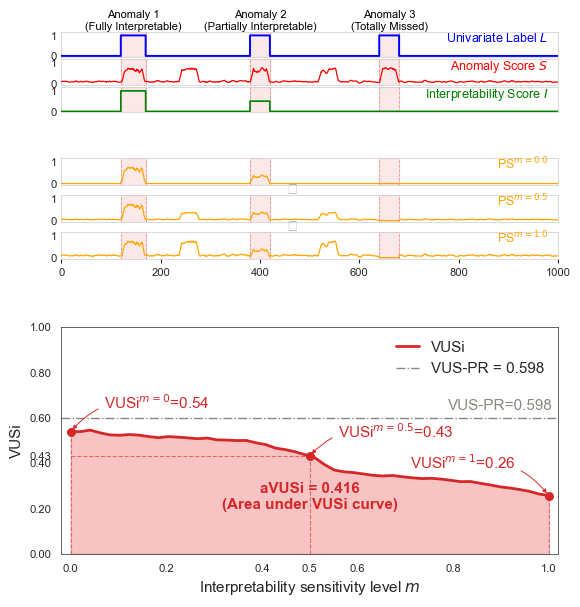

In [21]:
data = generate_avusi_demo_data(
    T=1000,
    anomaly_regions=[(120, 170), (380, 420), (640, 680)],
    seed=42,
)
print(f"aVUSi  = {data['aVUSi']:.3f}")
print(f"VUS-PR = {data['vus_pr']:.3f}")

fig = plot_avusi_pipeline(
    data=data,
    detector_name="Synthetic",
    figsize=(7, 6),
    save_path=os.path.join(OUTPUT_DIR, 'avusi_illustration'),
)

## Figure 1: Combined three-metrics boxplot — vertical (`plot_combined_three_metrics_boxplot`)

In [22]:
# fig = plot_combined_three_metrics_boxplot(
#     datasets_data,
#     save_path=os.path.join(OUTPUT_DIR, 'combined_three_metrics_boxplot.png'),
# )

## Figure 2: Combined three-metrics boxplot — horizontal (`plot_combined_three_metrics_boxplot_horizontal`)

/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_the paper.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=60)
/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_the paper.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=60)
/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_the paper.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=60)
/Users/macbook/PycharmProjects/aVUSi/reproduce_results/plot_figures_for_the paper.py:252: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/combined_three_metrics_boxplot_horizontal.png


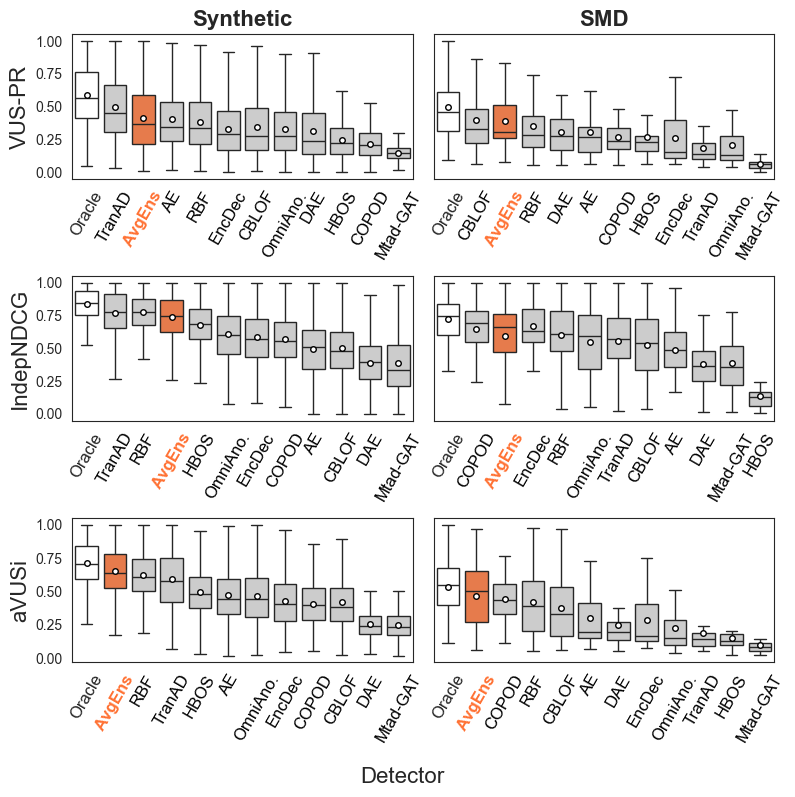

In [23]:
fig = plot_combined_three_metrics_boxplot_horizontal(
    datasets_data,
    save_path=os.path.join(OUTPUT_DIR, 'combined_three_metrics_boxplot_horizontal.png'),
)

## Figure 3: Combined average ranking (`plot_combined_average_ranking`)

Loaded cached metric_matrix: settings_six_data/metric_matrix.csv
Loaded cached metric_matrix: smd_data/metric_matrix.csv
Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/combined_average_ranking_plot.png


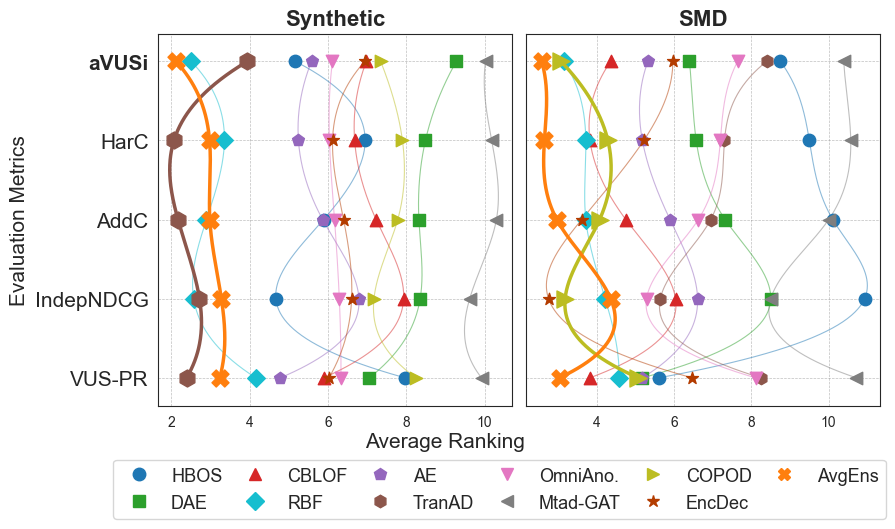

In [24]:
fig = plot_combined_average_ranking(
    datasets_data,
    save_path=os.path.join(OUTPUT_DIR, 'combined_average_ranking_plot.png'),
)

## Figure 3b: Critical difference diagram (`plot_critical_difference`)

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/combined_critical_difference_diagram.png


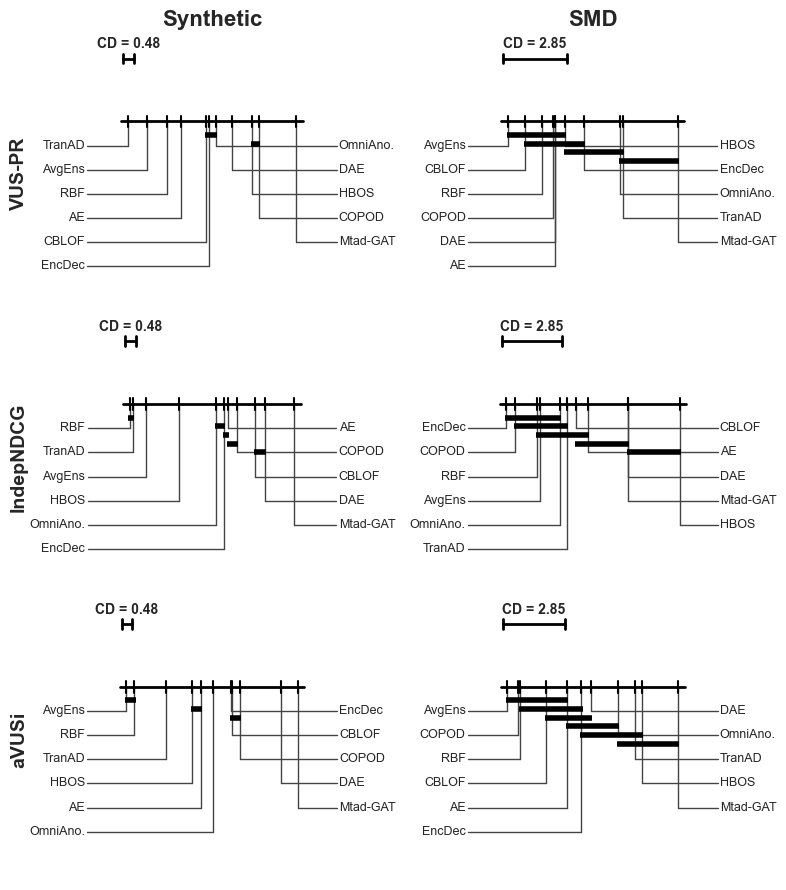

In [25]:
fig = plot_critical_difference(
    datasets_data,
    save_path=os.path.join(OUTPUT_DIR, 'combined_critical_difference_diagram.png'),
)

## Figure 4: Hyper-parameter sensitivity (`plot_combined_hyper_parameter_sensitivity`)

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/combined_all_hyper_parameters_sensitivity.png


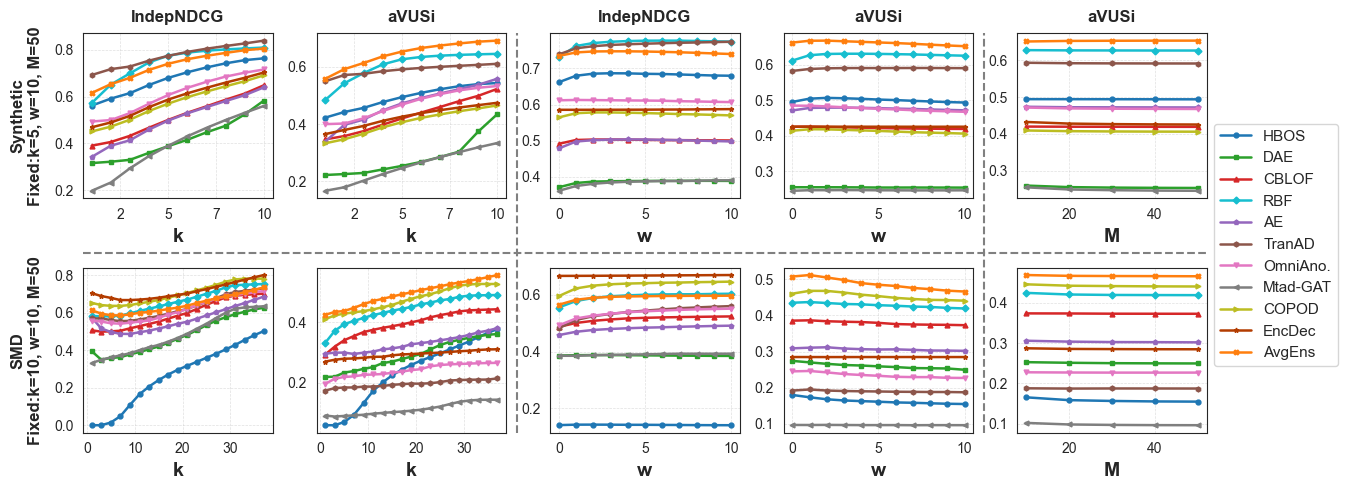

In [26]:
fig = plot_combined_hyper_parameter_sensitivity(
    datasets_data,
    hyper_parameters=['k', 'w', 'm'],
    save_path=os.path.join(OUTPUT_DIR, 'combined_all_hyper_parameters_sensitivity.png'),
)

## Figure 5: Computation time vs. hyperparameter (`plot_combined_computation_time`)

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/combined_computation_time_scalability.png


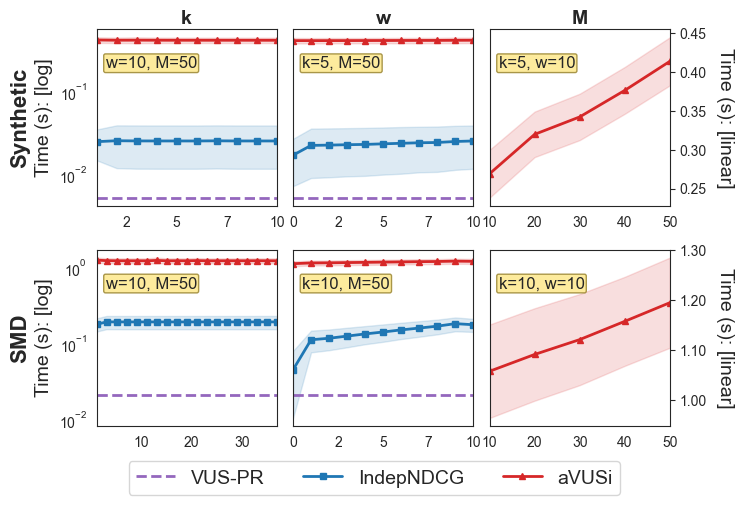

In [27]:
fig = plot_combined_computation_time(
    datasets_data,
    parameters=['k', 'w', 'm'],
    save_path=os.path.join(OUTPUT_DIR, 'combined_computation_time_scalability.png'),
)

## Figure 5b: Compact computation time — single-column layout (`plot_compact_computation_time`)

In [28]:
# fig = plot_compact_computation_time(
#     datasets_data,
#     parameters=['k', 'w', 'm'],
#     save_path=os.path.join(OUTPUT_DIR, 'compact_computation_time_scalability.png'),
# )

## Figure 6: Time complexity vs. series length (`plot_time_complexity_vs_series_length`)

In [29]:
# fig = plot_time_complexity_vs_series_length(
#     save_path=os.path.join(OUTPUT_DIR, 'time_complexity_vs_series_length.png'),
# )

## Metrics table for a single time series (`plot_metrics_for_a_single_time_series`)

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/metrics_for_time_series_synthetic_batch_999.out_in_settings_six.png


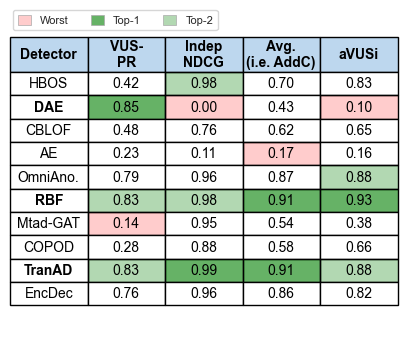

In [30]:
# Synthetic dataset
fig = plot_metrics_for_a_single_time_series(
    datasetname='settings_six',
    time_series_id='synthetic_batch_999.out',
    save_path=os.path.join(OUTPUT_DIR, 'metrics_for_time_series_synthetic_batch_999.out_in_settings_six.png'),
)

Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/metrics_for_time_series_machine-3-1.out_in_smd.png


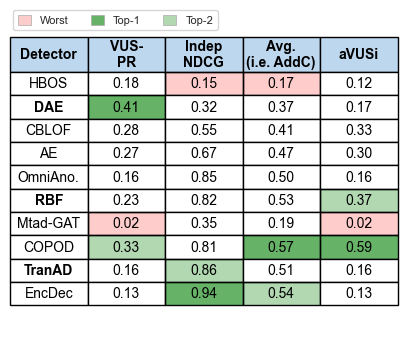

In [31]:
# SMD dataset
fig = plot_metrics_for_a_single_time_series(
    datasetname='smd',
    time_series_id='machine-3-1.out',
    save_path=os.path.join(OUTPUT_DIR, 'metrics_for_time_series_machine-3-1.out_in_smd.png'),
)

## aVUSi curve for a single time series (`plot_vusi_curve`)

number of legends 6
Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/vusi_curve_for_time_series_synthetic_batch_999.out_in_settings_six.png


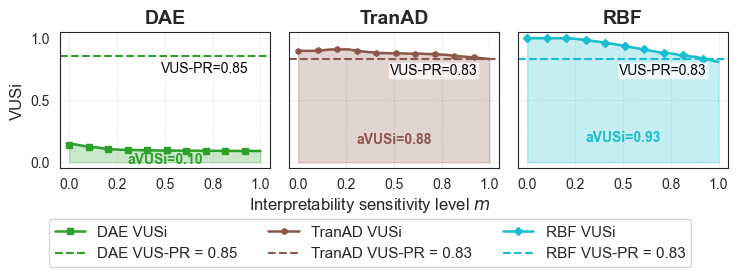

In [32]:
visualized_detectors = ['denoising_auto_encoder', 'tran_ad', 'random_black_forest']

# Synthetic dataset
fig = plot_vusi_curve(
    datasetname='settings_six',
    time_series_id='synthetic_batch_999.out',
    visualized_detectors=visualized_detectors,
    save_path=os.path.join(OUTPUT_DIR, 'vusi_curve_for_time_series_synthetic_batch_999.out_in_settings_six.png'),
)

number of legends 6
Saved: /Users/macbook/PycharmProjects/aVUSi/reproduce_results/combined_figures/vusi_curve_for_time_series_machine-3-1.out_in_smd.png


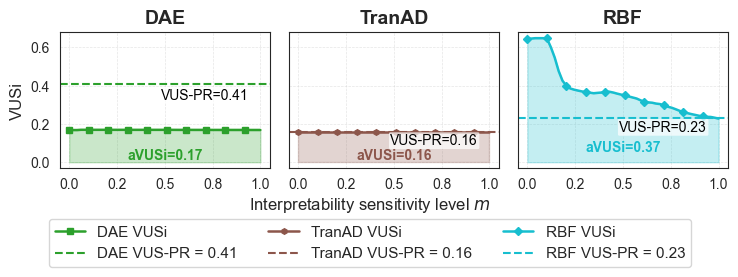

In [33]:
# SMD dataset
fig = plot_vusi_curve(
    datasetname='smd',
    time_series_id='machine-3-1.out',
    visualized_detectors=visualized_detectors,
    save_path=os.path.join(OUTPUT_DIR, 'vusi_curve_for_time_series_machine-3-1.out_in_smd.png'),
)